In [1]:
# Temel kütüphaneler
import pandas as pd
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

# Model selection ve cross-validation
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold, 
    GridSearchCV, validation_curve, learning_curve
)

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
# Classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Metrics
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, mean_squared_error, r2_score,
    precision_score, recall_score, f1_score
)

In [2]:
path = kagglehub.dataset_download("shrutimechlearn/churn-modelling")
csv_path = os.path.join(path, "Churn_Modelling.csv")
df = pd.read_csv(csv_path)
print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [3]:
# ====================================================================
#  CLASSIFICATION & EDA
# ====================================================================

In [4]:
print(f"Veri seti boyutu: {df.shape}")

Veri seti boyutu: (10000, 14)


In [5]:
print(f"Sütunlar: {df.columns.tolist()}")

Sütunlar: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [7]:
# 1.5 - Eksik Değer Analizi
print("\n" + "="*60)
print("EKSİK DEĞER ANALİZİ")
print("="*60)
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Eksik Sayısı': missing_values,
    'Yüzde (%)': missing_percent
}).sort_values('Eksik Sayısı', ascending=False)
print(missing_df[missing_df['Eksik Sayısı'] > 0])


EKSİK DEĞER ANALİZİ
Empty DataFrame
Columns: [Eksik Sayısı, Yüzde (%)]
Index: []


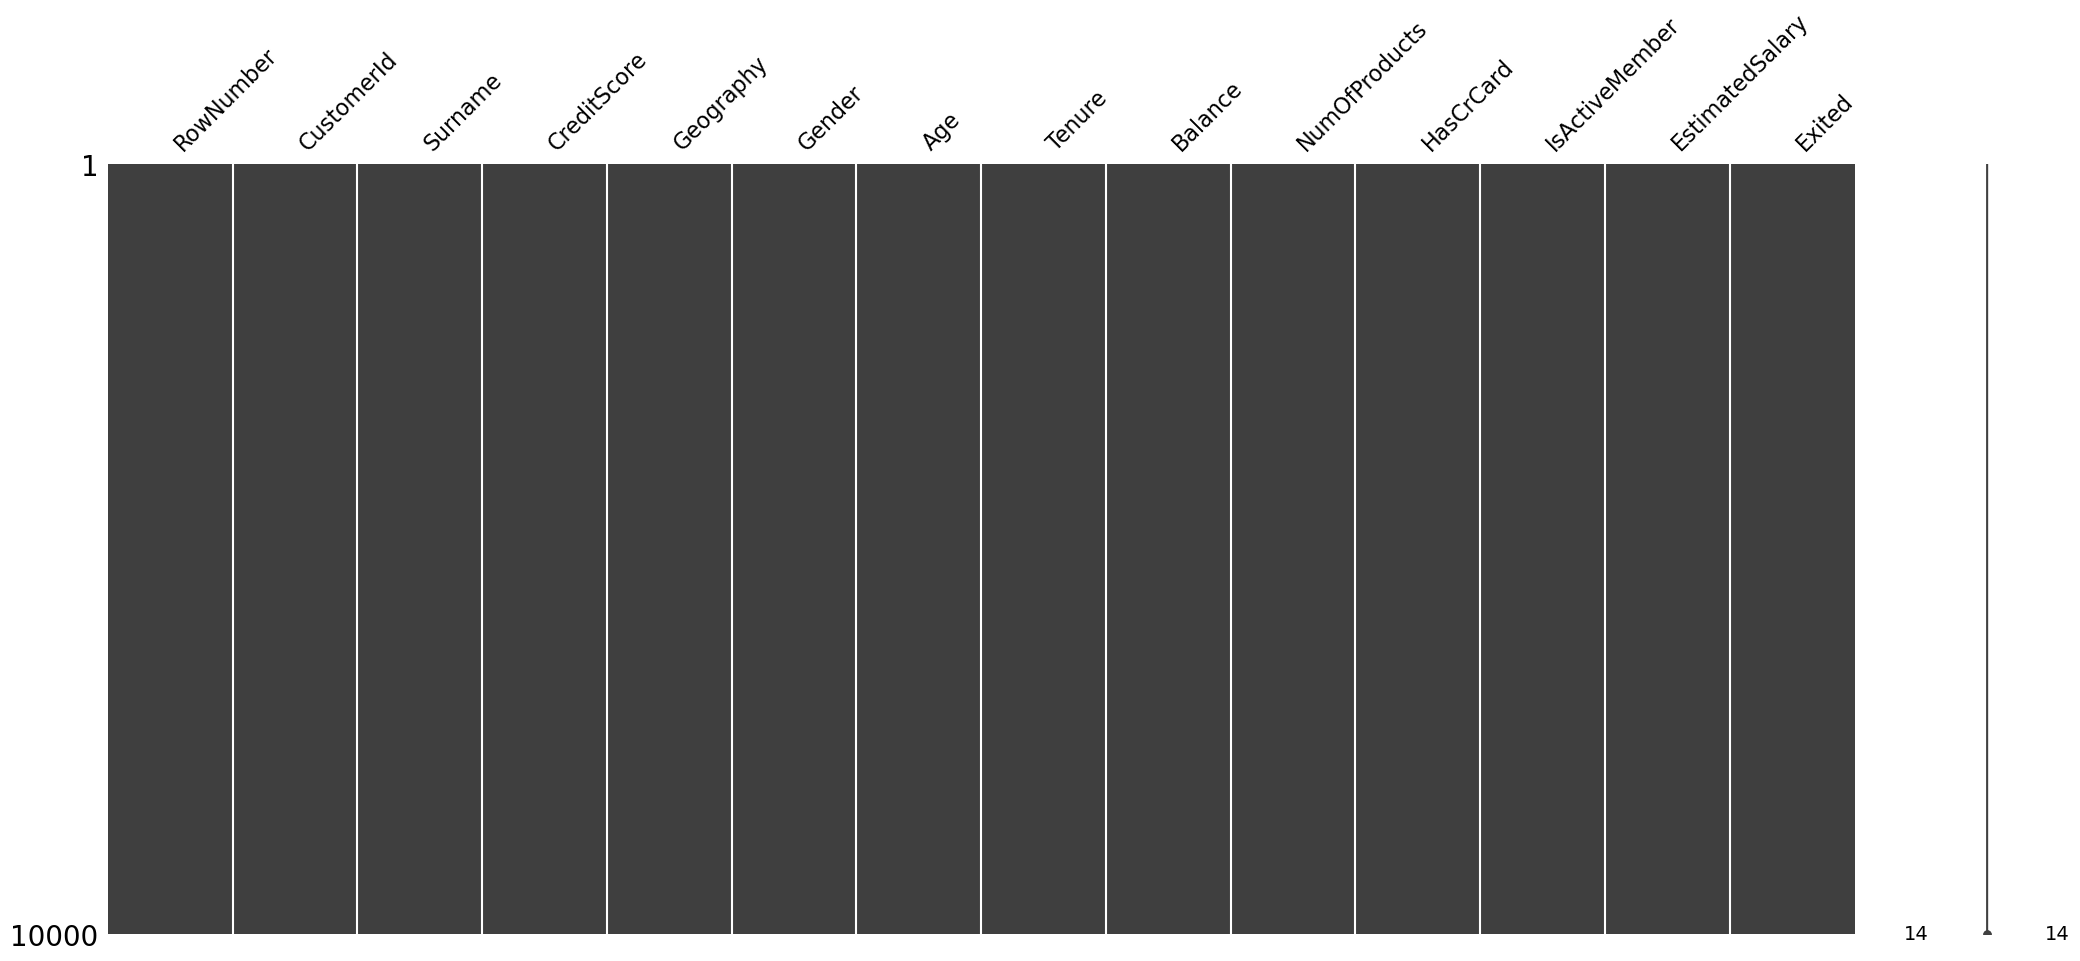

In [8]:
import missingno as msno
msno.matrix(df)
plt.show()


HEDEF DEĞİŞKEN ANALİZİ (Churn)
No Churn (0): 7963 müşteri (79.6%)
Churn (1): 2037 müşteri (20.4%)


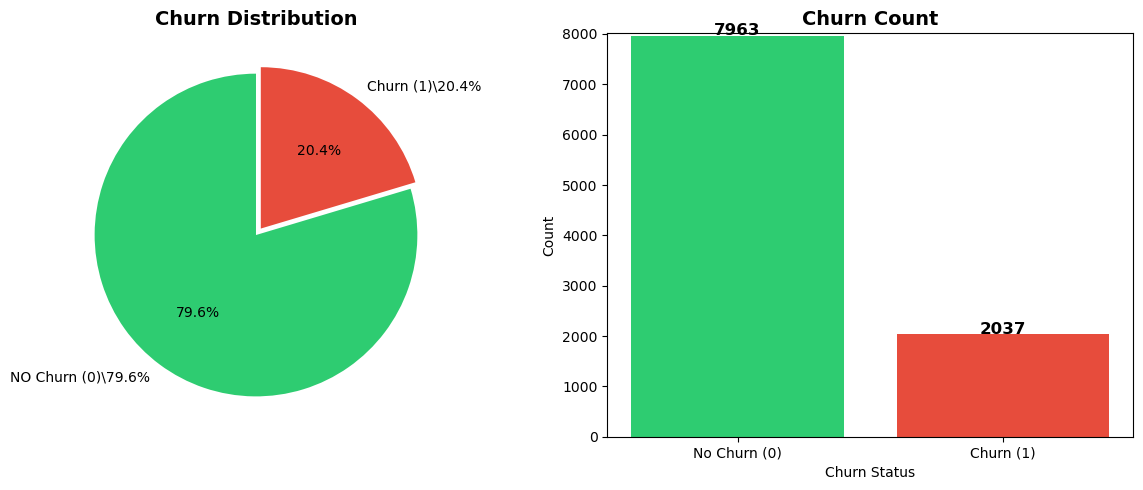

In [9]:
# 1.7 - Hedef Değişken (Churn) Dağılımı
print("\n" + "="*60)
print("HEDEF DEĞİŞKEN ANALİZİ (Churn)")
print("="*60)

churn_counts = df['Exited'].value_counts()
churn_percent = df['Exited'].value_counts(normalize=True)*100

churn_0_count = churn_counts.get(0, 0)
churn_1_count = churn_counts.get(1, 0)
churn_0_percent = churn_percent.get(0, 0)
churn_1_percent = churn_percent.get(1, 0)

print(f"No Churn (0): {churn_0_count} müşteri ({churn_0_percent:.1f}%)")
print(f"Churn (1): {churn_1_count} müşteri ({churn_1_percent:.1f}%)")

fig,axes = plt.subplots(1,2,figsize=(12,5))

#Pie Chart
axes[0].pie([churn_0_count,churn_1_count],
            labels=[f'NO Churn (0)\{churn_0_percent:.1f}%',
                    f'Churn (1)\{churn_1_percent:.1f}%'],
            autopct='%1.1f%%', 
            colors=['#2ecc71', '#e74c3c'], 
            startangle=90,
            explode=(0, 0.05))
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')

# Bar plot
bars = axes[1].bar(['No Churn (0)', 'Churn (1)'], 
                   [churn_0_count, churn_1_count], 
                   color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn Status')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, max(churn_0_count, churn_1_count) + 50)

for bar, count in zip(bars, [churn_0_count, churn_1_count]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
                 str(count), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

In [10]:
# ====================================================================
#  DATA PREPROCESSING & PIPELINES
# ====================================================================

In [11]:
# 2.1 - Gereksiz Sütunları Çıkar
columns=['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns,axis=1) 
# 2.1 - Gender sütunundaki Female değerleri 0 , male değerleri ise 1 yap
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [12]:
# 2.2 - Feature ve Target Ayır
X = df.drop('Exited',axis=1)
y = df['Exited']

print(f"\n Feature set shape : {X.shape}")
print(f"\n Target set shape : {y.shape}")


 Feature set shape : (10000, 10)

 Target set shape : (10000,)


In [13]:
# 2.3 - Sayısal ve Kategorik Sütunları Belirle
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nSayısal sütunlar ({len(numeric_features)}): {numeric_features}")
print(f"Kategorik sütunlar ({len(categorical_features)}): {categorical_features}")


Sayısal sütunlar (8): ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Kategorik sütunlar (1): ['Geography']


In [14]:
# 2.4 - Train-Test Split (Stratified - Class dengesini koru)
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.25,random_state=42,stratify=y
)

print(f"\nTrain seti boyutu: {X_train.shape[0]} örnek")
print(f"Test seti boyutu: {X_test.shape[0]} örnek")
print(f"Train seti Churn oranı: {y_train.mean()*100:.1f}%")
print(f"Test seti Churn oranı: {y_test.mean()*100:.1f}%")


Train seti boyutu: 7500 örnek
Test seti boyutu: 2500 örnek
Train seti Churn oranı: 20.4%
Test seti Churn oranı: 20.4%


In [15]:
# Verisetinde eksik veya kayıp veri yok ama olsaydı yapılacak işlemler
#Sayısal sütunlar için pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

# Kategorik sütunlar için pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("onehot",OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Preprocessor - İki pipeline'ı birleştir
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

    
print("\nPreprocessing pipeline başarıyla oluşturuldu.")
print("- Sayısal sütunlar: median imputation + StandardScaler")
print("- Kategorik sütunlar: mode imputation + OneHotEncoder")


Preprocessing pipeline başarıyla oluşturuldu.
- Sayısal sütunlar: median imputation + StandardScaler
- Kategorik sütunlar: mode imputation + OneHotEncoder


In [16]:
# 2.6 - Eksik Değer Kontrolü 
print("\n" + "="*60)
print("EKSİK DEĞER KONTROLÜ (PREPROCESSING ÖNCESİ)")
print("="*60)
print(f"Train seti eksik değer sayısı: {X_train.isnull().sum().sum()}")
print(f"Test seti eksik değer sayısı: {X_test.isnull().sum().sum()}")


EKSİK DEĞER KONTROLÜ (PREPROCESSING ÖNCESİ)
Train seti eksik değer sayısı: 0
Test seti eksik değer sayısı: 0


In [17]:
# ====================================================================
# CHAPTER 3: MODEL BUILDING & EVALUATION
# ====================================================================

In [18]:
# 3.1 - KNN Modeli ile Pipeline Oluştur
knn_pipeline = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model",KNeighborsClassifier(n_neighbors=5))
])
print("\n" + "="*60)
print("BASELINE KNN MODELİ")
print("="*60)

# model eğitme
knn_pipeline.fit(X_train,y_train)

#tahmin etme
y_pred = knn_pipeline.predict(X_test)
y_pred_proba = knn_pipeline.predict_proba(X_test)[:1]

#değerlendirme
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


BASELINE KNN MODELİ
Accuracy: 0.8404

Confusion Matrix:
[[1882  109]
 [ 290  219]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.90      1991
           1       0.67      0.43      0.52       509

    accuracy                           0.84      2500
   macro avg       0.77      0.69      0.71      2500
weighted avg       0.83      0.84      0.83      2500



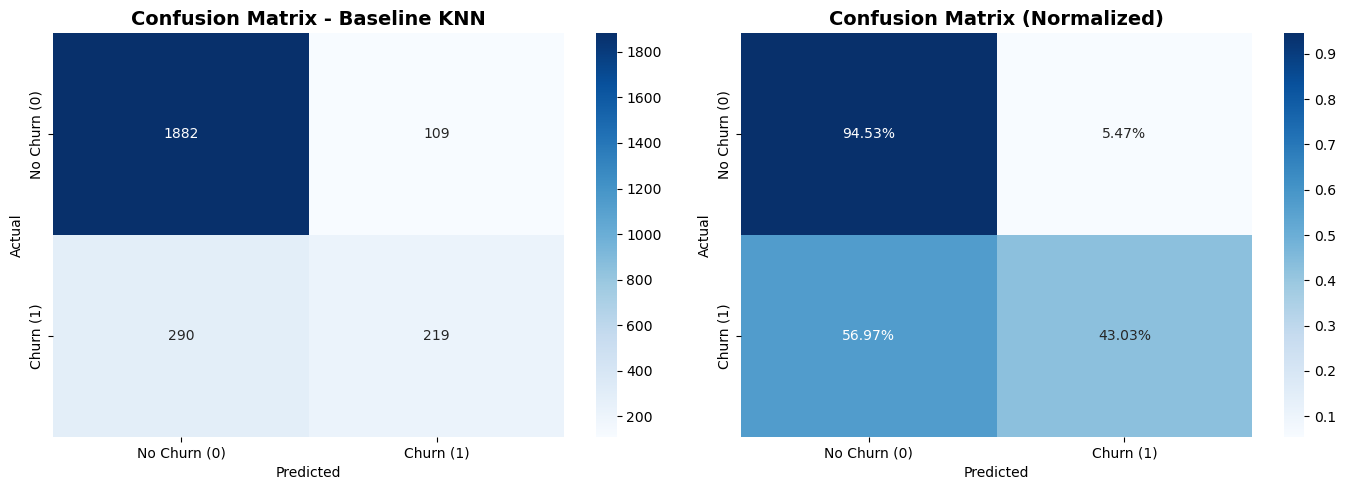

In [19]:
# 3.2 - Confusion Matrix Görselleştirme
fig,axes = plt.subplots(1,2,figsize=(14,5))
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d', cmap='Blues', ax=axes[0],
           xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
axes[0].set_title('Confusion Matrix - Baseline KNN', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalize edilmiş (oran)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

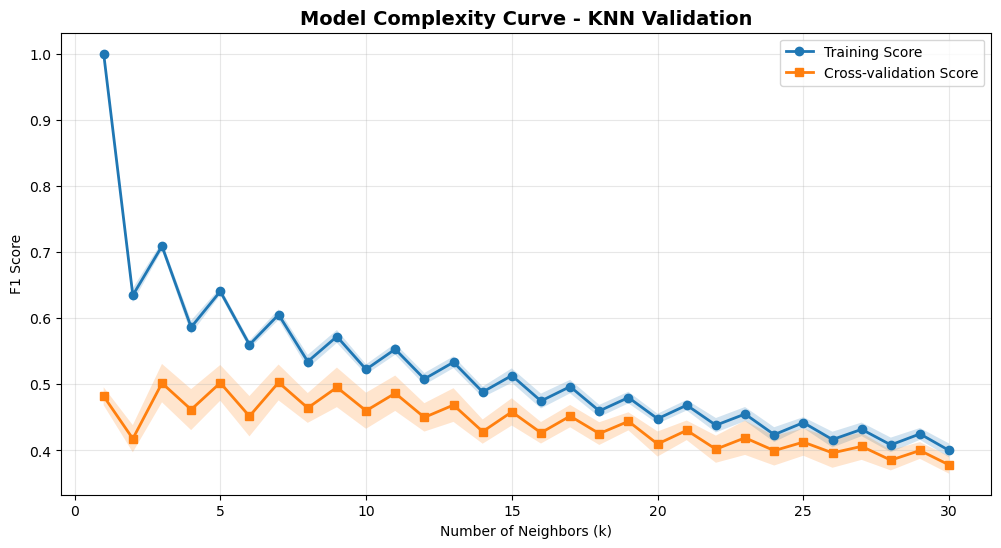

Validation curve'e göre en iyi k değeri: 7
En iyi CV F1 skoru: 0.5029


In [20]:
param_range = range(1, 31)
train_scores, test_scores = validation_curve(
    knn_pipeline, X_train, y_train,
    param_name='model__n_neighbors',
    param_range=param_range,
    cv=5,
    scoring='f1'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(param_range, train_mean, label='Training Score', marker='o', linewidth=2)
plt.plot(param_range, test_mean, label='Cross-validation Score', marker='s', linewidth=2)
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('F1 Score')
plt.title('Model Complexity Curve - KNN Validation', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# En iyi k değerini bul
best_k = param_range[np.argmax(test_mean)]
print(f"Validation curve'e göre en iyi k değeri: {best_k}")
print(f"En iyi CV F1 skoru: {test_mean.max():.4f}")

In [21]:
print("\n" + "="*60)
print("⚠️  BASİT KNN MODELİ ÇOK KÖTÜ PERFORMANS GÖSTERDİ!")
print("="*60)
print(f"KNN CV F1 Skoru: {test_mean.max():.4f}")
print(f"KNN En iyi k değeri: {best_k}")
print("\nNedenleri:")
print("1. Sınıf dengesizliği (Churn %20)")
print("2. KNN azınlık sınıfını öğrenmekte zorlanıyor")
print("3. k=7 Model gürültüye karşı dirençli ancak ayrıştırıcılığı düşük.")
print("\n🔧 ÇÖZÜM: Daha gelişmiş modeller kullanacağız!")
print("   - SMOTE ile veri dengeleme")
print("   - Random Forest (class_weight='balanced')")
print("   - XGBoost (scale_pos_weight)")
print("   - Logistic Regression (class_weight='balanced')")

# Gerekli kütüphaneler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score

# XGBoost için (pip install xgboost)
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False
    print("⚠️ XGBoost kurulu değil. 'pip install xgboost' ile kurabilirsiniz.")

print("\n" + "="*60)
print("🚀 GELİŞMİŞ MODELLER - SINIF DENGESİZLİĞİ ÇÖZÜMÜ")
print("="*60)

# 1. SMOTE ile KNN
print("\n1️⃣  SMOTE + KNN (Veri Dengeleme)")
smote_knn = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('knn', KNeighborsClassifier(n_neighbors=7, weights='distance', metric='manhattan'))
])

# 2. Random Forest (class_weight='balanced')
print("\n2️⃣  Random Forest (Sınıf Ağırlıkları)")
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(
        class_weight='balanced',
        n_estimators=100,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

# 3. Logistic Regression (class_weight='balanced')
print("\n3️⃣  Logistic Regression (Sınıf Ağırlıkları)")
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        C=0.1
    ))
])

# 4. XGBoost (scale_pos_weight)
models_dict = {
    'SMOTE + KNN': smote_knn,
    'Random Forest': rf_model,
    'Logistic Regression': lr_model
}

if xgb_available:
    print("\n4️⃣  XGBoost (Pozitif Sınıf Ağırlığı)")
    xgb_model = Pipeline([
        ('preprocessor', preprocessor),
        ('xgb', XGBClassifier(
            scale_pos_weight=4,
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss'
        ))
    ])
    models_dict['XGBoost'] = xgb_model


⚠️  BASİT KNN MODELİ ÇOK KÖTÜ PERFORMANS GÖSTERDİ!
KNN CV F1 Skoru: 0.5029
KNN En iyi k değeri: 7

Nedenleri:
1. Sınıf dengesizliği (Churn %20)
2. KNN azınlık sınıfını öğrenmekte zorlanıyor
3. k=7 Model gürültüye karşı dirençli ancak ayrıştırıcılığı düşük.

🔧 ÇÖZÜM: Daha gelişmiş modeller kullanacağız!
   - SMOTE ile veri dengeleme
   - Random Forest (class_weight='balanced')
   - XGBoost (scale_pos_weight)
   - Logistic Regression (class_weight='balanced')
⚠️ XGBoost kurulu değil. 'pip install xgboost' ile kurabilirsiniz.

🚀 GELİŞMİŞ MODELLER - SINIF DENGESİZLİĞİ ÇÖZÜMÜ

1️⃣  SMOTE + KNN (Veri Dengeleme)

2️⃣  Random Forest (Sınıf Ağırlıkları)

3️⃣  Logistic Regression (Sınıf Ağırlıkları)


In [22]:

print("\n" + "="*60)
print("📊 MODELLER DEĞERLENDİRİLİYOR...")
print("="*60)

results = {}

for name, model in models_dict.items():
    print(f"\n--- {name} ---")
    
    # Cross-validation (5-fold)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    results[name] = {
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std()
    }
    
    print(f"CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    
    # Modeli eğit
    model.fit(X_train, y_train)
    
    # Test seti tahminleri
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Test metrikleri
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_proba)
    
    results[name]['test_acc'] = test_acc
    results[name]['test_f1'] = test_f1
    results[name]['test_auc'] = test_auc
    
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test F1: {test_f1:.4f}")
    print(f"Test AUC: {test_auc:.4f}")

# SONUÇLARI KARŞILAŞTIR
print("\n" + "="*60)
print("🏆 MODEL KARŞILAŞTIRMASI")
print("="*60)

results_df = pd.DataFrame(results).T
print(results_df.round(4))

# En iyi modeli bul (CV F1'a göre)
best_model_name = results_df['cv_f1_mean'].idxmax()
best_model = models_dict[best_model_name]

print(f"\n🌟 EN İYİ MODEL: {best_model_name}")
print(f"   CV F1: {results_df.loc[best_model_name, 'cv_f1_mean']:.4f}")
print(f"   Test F1: {results_df.loc[best_model_name, 'test_f1']:.4f}")
print(f"   Test AUC: {results_df.loc[best_model_name, 'test_auc']:.4f}")


📊 MODELLER DEĞERLENDİRİLİYOR...

--- SMOTE + KNN ---
CV F1: 0.5165 (+/- 0.0102)
Test Accuracy: 0.7640
Test F1: 0.5340
Test AUC: 0.7896

--- Random Forest ---
CV F1: 0.6119 (+/- 0.0114)
Test Accuracy: 0.8348
Test F1: 0.6242
Test AUC: 0.8684

--- Logistic Regression ---
CV F1: 0.4767 (+/- 0.0052)
Test Accuracy: 0.7188
Test F1: 0.5115
Test AUC: 0.7796

🏆 MODEL KARŞILAŞTIRMASI
                     cv_f1_mean  cv_f1_std  test_acc  test_f1  test_auc
SMOTE + KNN              0.5165     0.0102    0.7640   0.5340    0.7896
Random Forest            0.6119     0.0114    0.8348   0.6242    0.8684
Logistic Regression      0.4767     0.0052    0.7188   0.5115    0.7796

🌟 EN İYİ MODEL: Random Forest
   CV F1: 0.6119
   Test F1: 0.6242
   Test AUC: 0.8684


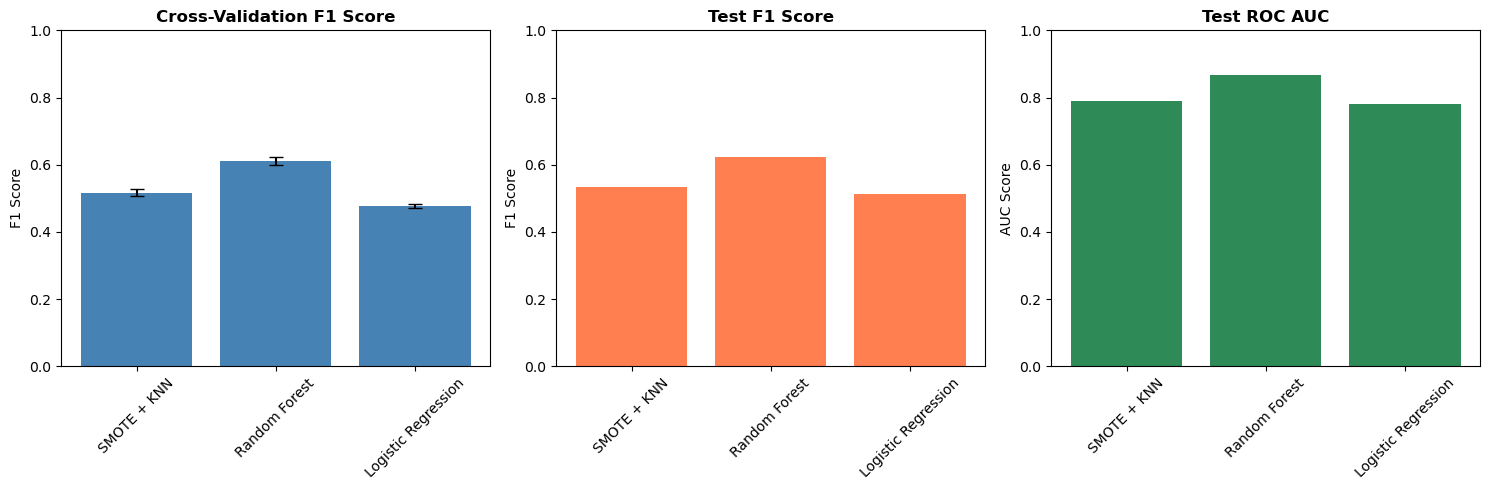

In [23]:

# Model karşılaştırma grafiği
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# CV F1 Karşılaştırması
bars1 = axes[0].bar(results_df.index, results_df['cv_f1_mean'], 
                    yerr=results_df['cv_f1_std'], capsize=5, color='steelblue')
axes[0].set_title('Cross-Validation F1 Score', fontsize=12, fontweight='bold')
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)

# Test F1 Karşılaştırması
bars2 = axes[1].bar(results_df.index, results_df['test_f1'], color='coral')
axes[1].set_title('Test F1 Score', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)

# Test AUC Karşılaştırması
bars3 = axes[2].bar(results_df.index, results_df['test_auc'], color='seagreen')
axes[2].set_title('Test ROC AUC', fontsize=12, fontweight='bold')
axes[2].set_ylabel('AUC Score')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


📈 EN İYİ MODEL (Random Forest) - ROC CURVE


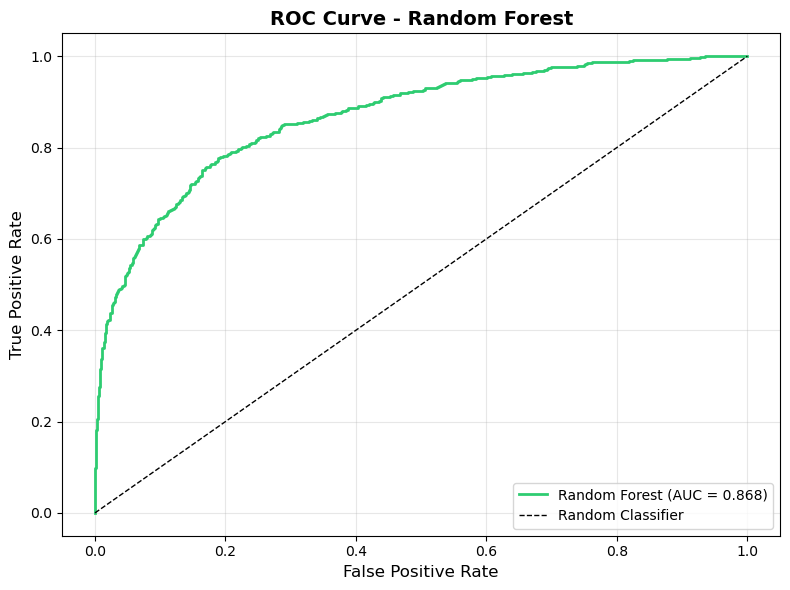

In [24]:
# EN İYİ MODEL İLE ROC CURVE
print("\n" + "="*60)
print(f"📈 EN İYİ MODEL ({best_model_name}) - ROC CURVE")
print("="*60)

y_proba_best = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
auc_best = roc_auc_score(y_test, y_proba_best)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc_best:.3f})', linewidth=2, color='#2ecc71')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve - {best_model_name}', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


📊 KARŞILAŞTIRMALI CONFUSION MATRIX


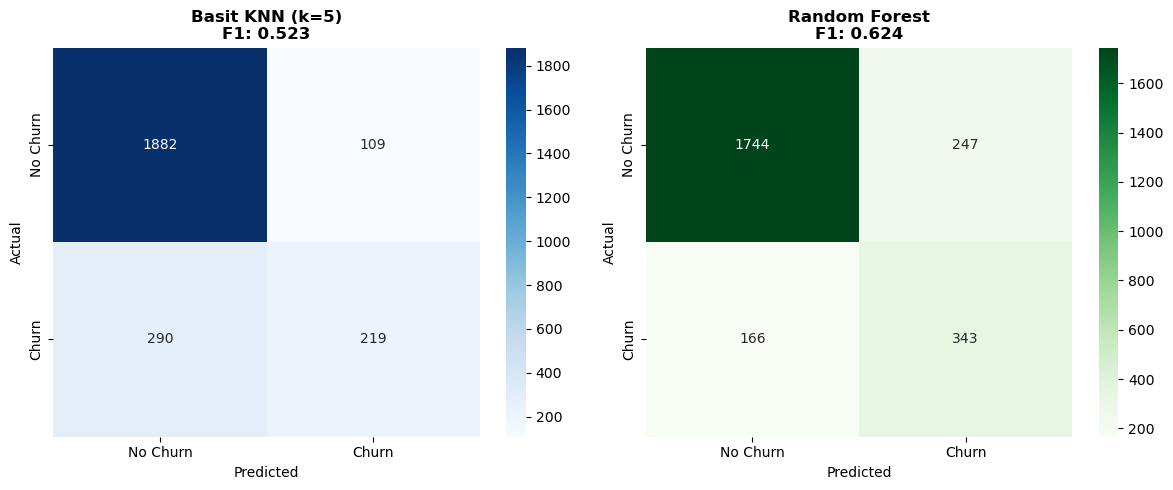


✅ GELİŞMİŞ MODELLER BAŞARIYLA EKLENDİ!
   İyileştirme: 0.121 F1 skoru artışı!


In [25]:
# KARŞILAŞTIRMALI CONFUSION MATRIX
print("\n" + "="*60)
print("📊 KARŞILAŞTIRMALI CONFUSION MATRIX")
print("="*60)

y_pred_knn = knn_pipeline.predict(X_test)
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Basit KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[0].set_title(f'Basit KNN (k=5)\nF1: {f1_score(y_test, y_pred_knn):.3f}', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# En iyi model
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[1].set_title(f'{best_model_name}\nF1: {results_df.loc[best_model_name, "test_f1"]:.3f}', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print("\n✅ GELİŞMİŞ MODELLER BAŞARIYLA EKLENDİ!")
print(f"   İyileştirme: {results_df.loc[best_model_name, 'test_f1'] - test_mean.max():.3f} F1 skoru artışı!")


In [26]:
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print("\n" + "="*60)
print("EN İYİ MODEL - TEST SETİ DEĞERLENDİRMESİ")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))


EN İYİ MODEL - TEST SETİ DEĞERLENDİRMESİ
Accuracy: 0.8348

Confusion Matrix:
[[1744  247]
 [ 166  343]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1991
           1       0.58      0.67      0.62       509

    accuracy                           0.83      2500
   macro avg       0.75      0.77      0.76      2500
weighted avg       0.85      0.83      0.84      2500



In [27]:
# ====================================================================
# ROC CURVE & AUC (Fine-Tuning)
# ====================================================================

In [28]:
# 5.1 - ROC Curve Hesapla
fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)
auc = roc_auc_score(y_test, y_proba_best)


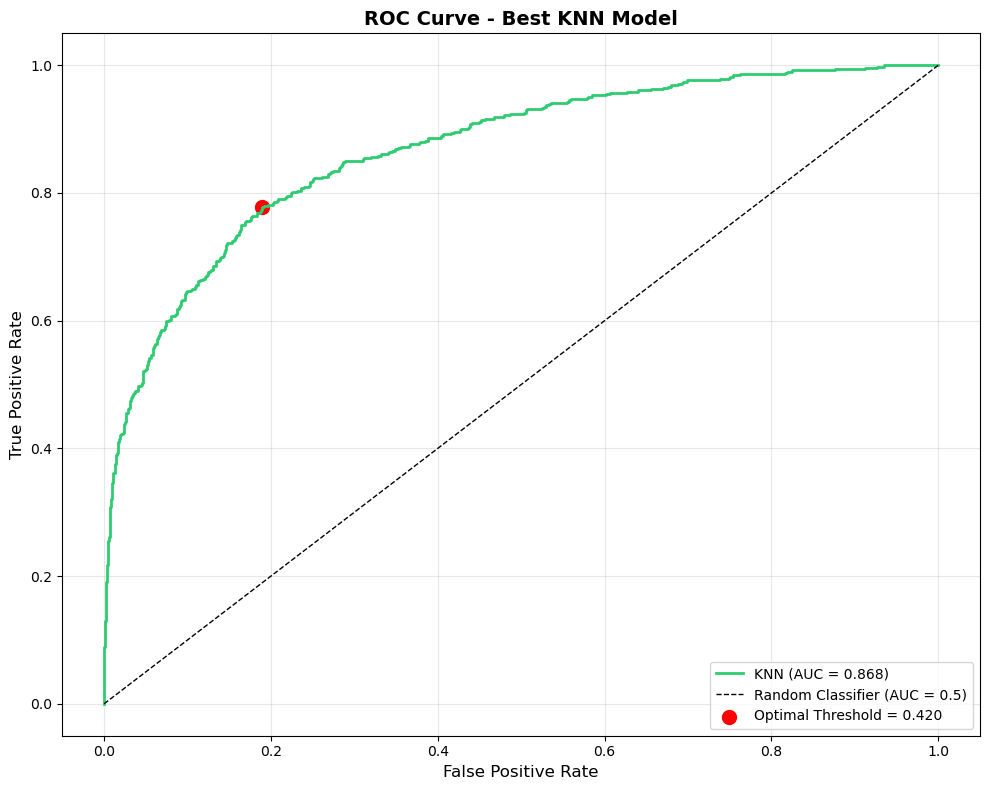


AUC (Area Under Curve) Score: 0.8684
Optimal threshold: 0.4199


In [29]:
# 5.2 - ROC Curve Görselleştir
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'KNN (AUC = {auc:.3f})', linewidth=2, color='#2ecc71')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)', linewidth=1)

# Optimal threshold bul (Youden's J statistic)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100, 
            label=f'Optimal Threshold = {optimal_threshold:.3f}')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Best KNN Model', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAUC (Area Under Curve) Score: {auc:.4f}")
print(f"Optimal threshold: {optimal_threshold:.4f}")

In [30]:
# ====================================================================
#  CROSS-VALIDATION
# ====================================================================

In [31]:
# 6.1 - Cross-validation ile Değerlendirme
print("\n" + "="*60)
print("CROSS-VALIDATION DEĞERLENDİRMESİ")
print("="*60)

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='f1')
print(f"5-fold CV F1 skorları: {cv_scores}")
print(f"Ortalama F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


CROSS-VALIDATION DEĞERLENDİRMESİ
5-fold CV F1 skorları: [0.60496614 0.62780269 0.62653289 0.62568606 0.61877173]
Ortalama F1: 0.6208 (+/- 0.0085)


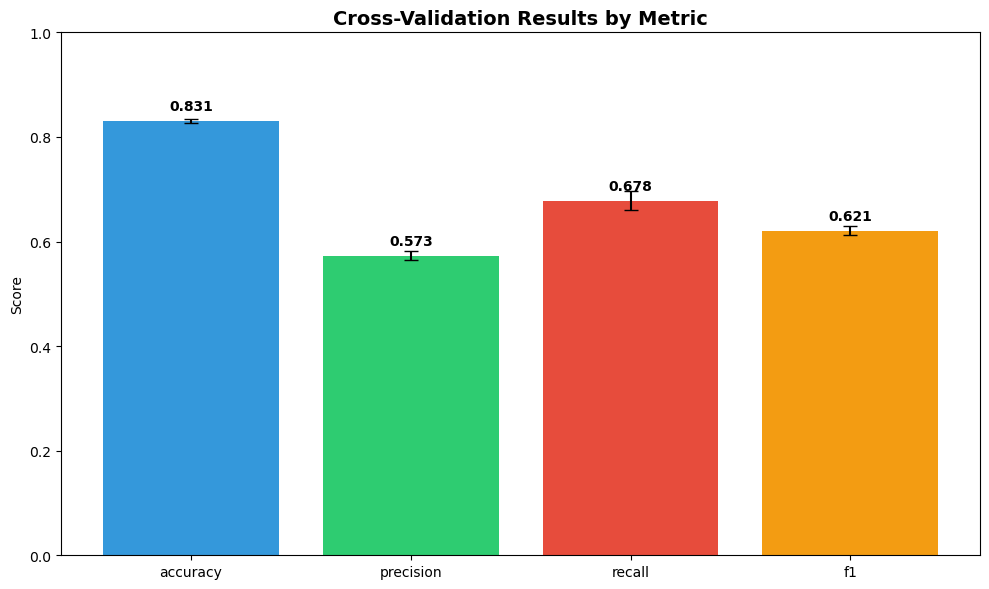

In [32]:
# 6.2 - Farklı metrikler için CV
metrics = ['accuracy', 'precision', 'recall', 'f1']
cv_results = {}

for metric in metrics:
    scores = cross_val_score(best_model, X, y, cv=5, scoring=metric)
    cv_results[metric] = {
        'mean': scores.mean(),
        'std': scores.std()
    }

# Görselleştir
fig, ax = plt.subplots(figsize=(10, 6))
metrics_names = list(cv_results.keys())
means = [cv_results[m]['mean'] for m in metrics_names]
stds = [cv_results[m]['std'] for m in metrics_names]

bars = ax.bar(metrics_names, means, yerr=stds, capsize=5, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Cross-Validation Results by Metric', fontsize=14, fontweight='bold')

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{mean:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [33]:
# ====================================================================
# REGRESSION MODELS
# ====================================================================

In [41]:
# Regression için target belirle 
y_reg = df['EstimatedSalary']
X_reg = df.drop(['Exited', 'EstimatedSalary', 'Balance','CreditScore'], axis=1)

print(f"\Yeni y_reg NaN sayısı: {y_reg.isnull().sum()}")

\Yeni y_reg NaN sayısı: 0


In [42]:
# 3. Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"\nTrain-test split sonrası:")
print(f"X_train_reg NaN sayısı: {X_train_reg.isnull().sum().sum()}")
print(f"X_test_reg NaN sayısı: {X_test_reg.isnull().sum().sum()}")
print(f"y_train_reg NaN sayısı: {y_train_reg.isnull().sum()}")
print(f"y_test_reg NaN sayısı: {y_test_reg.isnull().sum()}")


Train-test split sonrası:
X_train_reg NaN sayısı: 0
X_test_reg NaN sayısı: 0
y_train_reg NaN sayısı: 0
y_test_reg NaN sayısı: 0


In [43]:
# 4. Regression için sayısal ve kategorik sütunları belirle
numeric_features_reg = X_reg.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features_reg = X_reg.select_dtypes(include=['object']).columns.tolist()

print(f"\nSayısal sütunlar ({len(numeric_features_reg)}): {numeric_features_reg}")
print(f"Kategorik sütunlar ({len(categorical_features_reg)}): {categorical_features_reg}")

# 5. Preprocessor pipeline'ları
numeric_transformer_reg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_reg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_reg, numeric_features_reg),
        ('cat', categorical_transformer_reg, categorical_features_reg)
    ])


Sayısal sütunlar (5): ['Age', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']
Kategorik sütunlar (1): ['Geography']


In [44]:
# 6. Linear Regression
print("\n" + "="*60)
print("7.1 - Linear Regression")
print("="*60)

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train_reg, y_train_reg)
y_pred_lr = lr_pipeline.predict(X_test_reg)

print(f"R² Score: {r2_score(y_test_reg, y_pred_lr):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_lr)):.4f}")

# 7. Ridge Regression
print("\n" + "="*60)
print("7.2 - Ridge Regression")
print("="*60)

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('model', Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train_reg, y_train_reg)
y_pred_ridge = ridge_pipeline.predict(X_test_reg)

print(f"R² Score: {r2_score(y_test_reg, y_pred_ridge):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge)):.4f}")

# 8. Lasso Regression
print("\n" + "="*60)
print("7.3 - Lasso Regression")
print("="*60)

lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('model', Lasso(alpha=0.01, max_iter=10000))
])

lasso_pipeline.fit(X_train_reg, y_train_reg)
y_pred_lasso = lasso_pipeline.predict(X_test_reg)

print(f"R² Score: {r2_score(y_test_reg, y_pred_lasso):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_lasso)):.4f}")


7.1 - Linear Regression
R² Score: -0.0033
RMSE: 57550.7003

7.2 - Ridge Regression
R² Score: -0.0033
RMSE: 57550.6851

7.3 - Lasso Regression
R² Score: -0.0033
RMSE: 57550.6995


In [45]:
# 9. Ridge Regression Alpha Tuning
print("\n" + "="*60)
print("7.4 - Ridge Regression: Alpha Tuning")
print("="*60)

from sklearn.model_selection import GridSearchCV

param_grid_ridge = {'model__alpha': np.logspace(-4, 2, 20)}
ridge_cv = GridSearchCV(ridge_pipeline, param_grid_ridge, cv=5, scoring='r2', n_jobs=-1)
ridge_cv.fit(X_train_reg, y_train_reg)

print(f"En iyi alpha: {ridge_cv.best_params_['model__alpha']:.4f}")
print(f"En iyi CV R²: {ridge_cv.best_score_:.4f}")

# 10. En iyi Ridge model ile test
best_ridge = ridge_cv.best_estimator_
y_pred_best_ridge = best_ridge.predict(X_test_reg)

print(f"\nEn iyi Ridge Model Test R²: {r2_score(y_test_reg, y_pred_best_ridge):.4f}")
print(f"En iyi Ridge Model Test RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_best_ridge)):.4f}")

print("\n✅ REGRESYON MODELLERİ BAŞARIYLA ÇALIŞTI!")


7.4 - Ridge Regression: Alpha Tuning
En iyi alpha: 100.0000
En iyi CV R²: -0.0025

En iyi Ridge Model Test R²: -0.0032
En iyi Ridge Model Test RMSE: 57549.2307

✅ REGRESYON MODELLERİ BAŞARIYLA ÇALIŞTI!


In [46]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'),
    'SVM': SVC(random_state=42, probability=True, class_weight='balanced')
}
model_results = {}

for name, model in models.items():
    print(f"\n--- {name} ---")
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Eğit
    pipeline.fit(X_train, y_train)
    
    # Tahmin
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline, "predict_proba") else None
    
    # Metrikler
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # CV skorları
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1')
    
    # ROC AUC (eğer predict_proba varsa)
    auc = None
    if y_proba is not None:
        from sklearn.metrics import roc_auc_score
        auc = roc_auc_score(y_test, y_proba)
    
    model_results[name] = {
        'accuracy': accuracy,
        'f1': f1,
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std(),
        'auc': auc
    }
    
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test F1: {f1:.4f}")
    print(f"CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    if auc:
        print(f"Test AUC: {auc:.4f}")



--- Logistic Regression ---
Test Accuracy: 0.7188
Test F1: 0.5115
CV F1: 0.4758 (+/- 0.0061)
Test AUC: 0.7794

--- KNN (k=5) ---
Test Accuracy: 0.8404
Test F1: 0.5233
CV F1: 0.5023 (+/- 0.0270)
Test AUC: 0.7908

--- Decision Tree ---
Test Accuracy: 0.7852
Test F1: 0.4751
CV F1: 0.4790 (+/- 0.0392)
Test AUC: 0.6706

--- Random Forest ---
Test Accuracy: 0.8632
Test F1: 0.5839
CV F1: 0.5514 (+/- 0.0201)
Test AUC: 0.8591

--- SVM ---
Test Accuracy: 0.7960
Test F1: 0.6003
CV F1: 0.5858 (+/- 0.0138)
Test AUC: 0.8563


In [47]:
# 8.3 - Sonuçları Tablo Olarak Göster
results_df = pd.DataFrame(model_results).T

print("\n" + "="*60)
print("TÜM MODELLERİN SONUÇLARI")
print("="*60)
print(results_df.round(4))


TÜM MODELLERİN SONUÇLARI
                     accuracy      f1  cv_f1_mean  cv_f1_std     auc
Logistic Regression    0.7188  0.5115      0.4758     0.0061  0.7794
KNN (k=5)              0.8404  0.5233      0.5023     0.0270  0.7908
Decision Tree          0.7852  0.4751      0.4790     0.0392  0.6706
Random Forest          0.8632  0.5839      0.5514     0.0201  0.8591
SVM                    0.7960  0.6003      0.5858     0.0138  0.8563


In [48]:
 #8.4 - En İyi Modeli Bul (F1 Skoruna Göre)
best_model_name = results_df['f1'].idxmax()
best_accuracy_name = results_df['accuracy'].idxmax()
best_cv_name = results_df['cv_f1_mean'].idxmax()

print(f"\n🏆 EN İYİ MODEL (Test F1'e Göre): {best_model_name}")
print(f"   Test F1: {results_df.loc[best_model_name, 'f1']:.4f}")
print(f"   Test Accuracy: {results_df.loc[best_model_name, 'accuracy']:.4f}")

print(f"\n🎯 EN İYİ MODEL (Test Accuracy'e Göre): {best_accuracy_name}")
print(f"   Test Accuracy: {results_df.loc[best_accuracy_name, 'accuracy']:.4f}")
print(f"   Test F1: {results_df.loc[best_accuracy_name, 'f1']:.4f}")

print(f"\n📊 EN İYİ MODEL (CV F1'e Göre): {best_cv_name}")
print(f"   CV F1 Mean: {results_df.loc[best_cv_name, 'cv_f1_mean']:.4f}")
print(f"   CV F1 Std: {results_df.loc[best_cv_name, 'cv_f1_std']:.4f}")


🏆 EN İYİ MODEL (Test F1'e Göre): SVM
   Test F1: 0.6003
   Test Accuracy: 0.7960

🎯 EN İYİ MODEL (Test Accuracy'e Göre): Random Forest
   Test Accuracy: 0.8632
   Test F1: 0.5839

📊 EN İYİ MODEL (CV F1'e Göre): SVM
   CV F1 Mean: 0.5858
   CV F1 Std: 0.0138


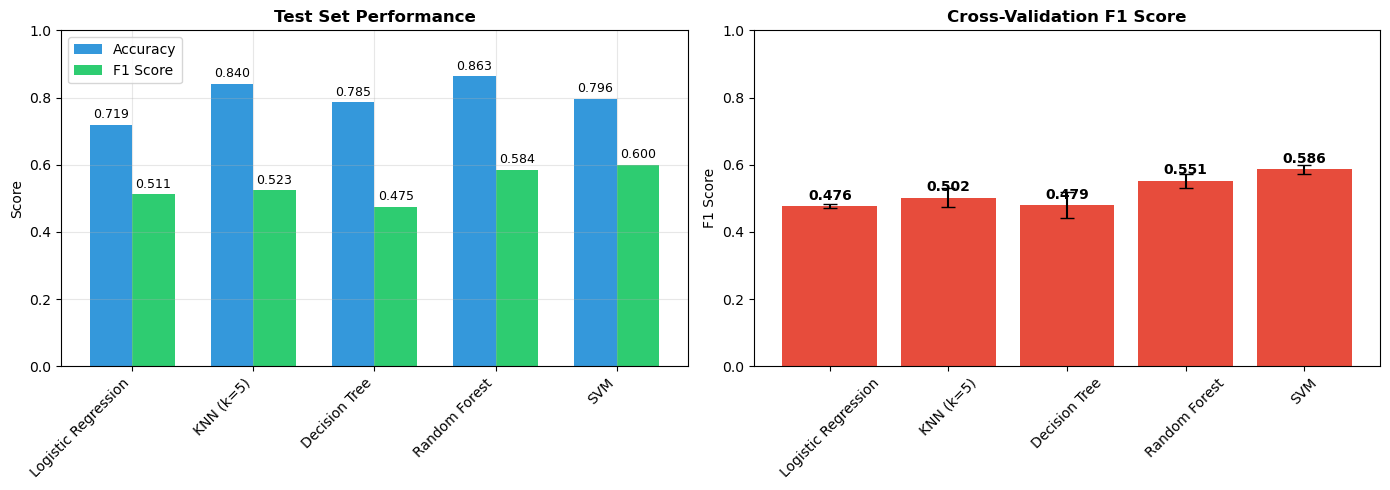

In [49]:
# 8.5 - Görselleştirmeler 

# Test Set Performance Grafiği
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy ve F1 karşılaştırması
x = np.arange(len(results_df.index))
width = 0.35

bars1 = axes[0].bar(x - width/2, results_df['accuracy'], width, label='Accuracy', color='#3498db')
bars2 = axes[0].bar(x + width/2, results_df['f1'], width, label='F1 Score', color='#2ecc71')

axes[0].set_title('Test Set Performance', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df.index, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Değerleri etiketle
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)

# CV F1 Grafiği
bars3 = axes[1].bar(results_df.index, results_df['cv_f1_mean'], 
                    yerr=results_df['cv_f1_std'], capsize=5, color='#e74c3c')
axes[1].set_title('Cross-Validation F1 Score', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)

for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{bar.get_height():.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

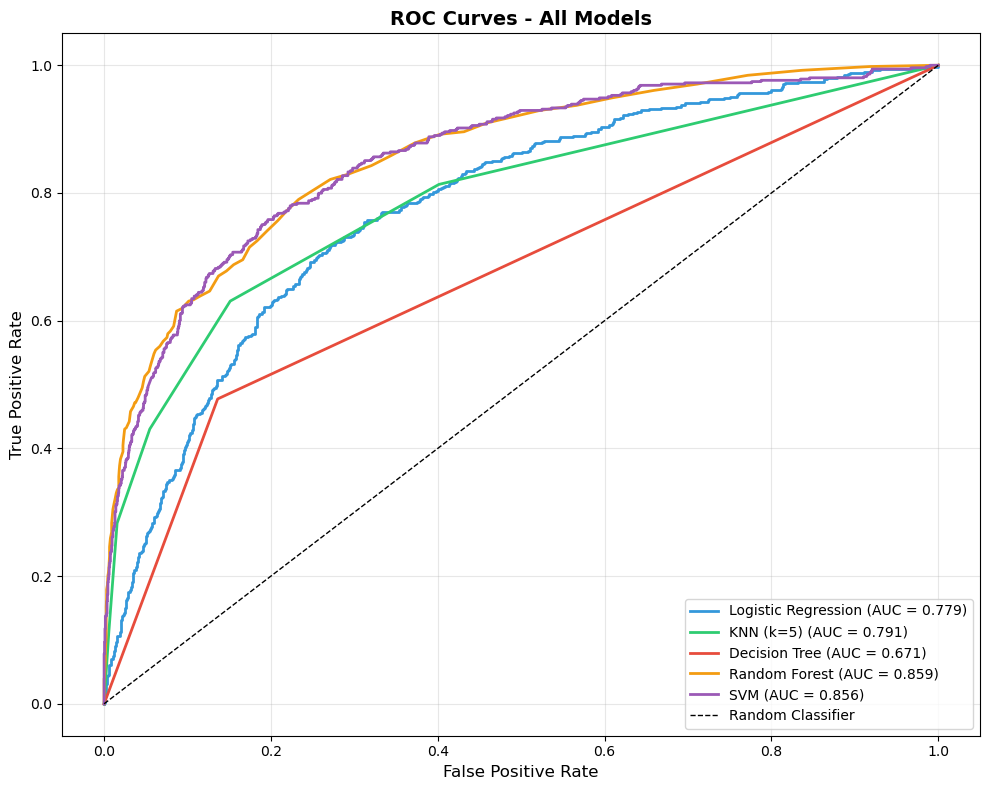

In [50]:
# 8.6 - Görselleştirme 2: ROC Curves (Sınıflandırma Modelleri İçin)
plt.figure(figsize=(10, 8))

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
for (name, model), color in zip(models.items(), colors):
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    
    if hasattr(pipeline, "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [53]:
# 8.7 - Random Forest Performans Analizi
print("\n" + "="*60)
print("⚠️ MODEL PERFORMANS ANALİZİ")
print("="*60)

# Her modelin tahmin dağılımını göster
for name, model in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    pred_0 = np.sum(y_pred == 0)
    pred_1 = np.sum(y_pred == 1)
    actual_0 = np.sum(y_test == 0)
    actual_1 = np.sum(y_test == 1)
    
    print(f"\n--- {name} ---")
    print(f"Tahmin edilen 0 sayısı: {pred_0} (Gerçek: {actual_0})")
    print(f"Tahmin edilen 1 sayısı: {pred_1} (Gerçek: {actual_1})")
    
    if pred_1 == 0:
        print(f"⚠️ UYARI: Model hiç Churn (1) tahmini yapmadı!")



⚠️ MODEL PERFORMANS ANALİZİ

--- Logistic Regression ---
Tahmin edilen 0 sayısı: 1570 (Gerçek: 1991)
Tahmin edilen 1 sayısı: 930 (Gerçek: 509)

--- KNN (k=5) ---
Tahmin edilen 0 sayısı: 2172 (Gerçek: 1991)
Tahmin edilen 1 sayısı: 328 (Gerçek: 509)

--- Decision Tree ---
Tahmin edilen 0 sayısı: 1986 (Gerçek: 1991)
Tahmin edilen 1 sayısı: 514 (Gerçek: 509)

--- Random Forest ---
Tahmin edilen 0 sayısı: 2187 (Gerçek: 1991)
Tahmin edilen 1 sayısı: 313 (Gerçek: 509)

--- SVM ---
Tahmin edilen 0 sayısı: 1733 (Gerçek: 1991)
Tahmin edilen 1 sayısı: 767 (Gerçek: 509)


In [54]:
# 8.8 - En İyi Modeli Kaydet
best_model_final = Pipeline([
    ('preprocessor', preprocessor),
    ('model', models[best_model_name])
])
best_model_final.fit(X_train, y_train)

print(f"\n" + "="*60)
print(f"✅ EN İYİ MODEL KAYDEDİLDİ: {best_model_name}")
print("="*60)
print(f"Model ile tekrar test ediliyor...")

# En iyi model ile son test
y_pred_final = best_model_final.predict(X_test)
y_proba_final = best_model_final.predict_proba(X_test)[:, 1]

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Test F1 Score: {f1_score(y_test, y_pred_final, zero_division=0):.4f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_final):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))



✅ EN İYİ MODEL KAYDEDİLDİ: SVM
Model ile tekrar test ediliyor...

Test Accuracy: 0.7960
Test F1 Score: 0.6003
Test AUC: 0.8563

Confusion Matrix:
[[1607  384]
 [ 126  383]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.86      1991
           1       0.50      0.75      0.60       509

    accuracy                           0.80      2500
   macro avg       0.71      0.78      0.73      2500
weighted avg       0.84      0.80      0.81      2500



In [55]:
# ====================================================================
# FEATURE IMPORTANCE (Lasso)
# ====================================================================


FEATURE IMPORTANCE ANALYSIS

Top 10 En Önemli Özellikler:
             feature  coefficient
8  Geography_Germany     0.125650
1                Age     0.111191
6     IsActiveMember    -0.067674
3            Balance     0.019369
0        CreditScore    -0.010299
7    EstimatedSalary     0.006862
4      NumOfProducts    -0.006320
5          HasCrCard    -0.001709
2             Tenure     0.000000
9    Geography_Spain     0.000000


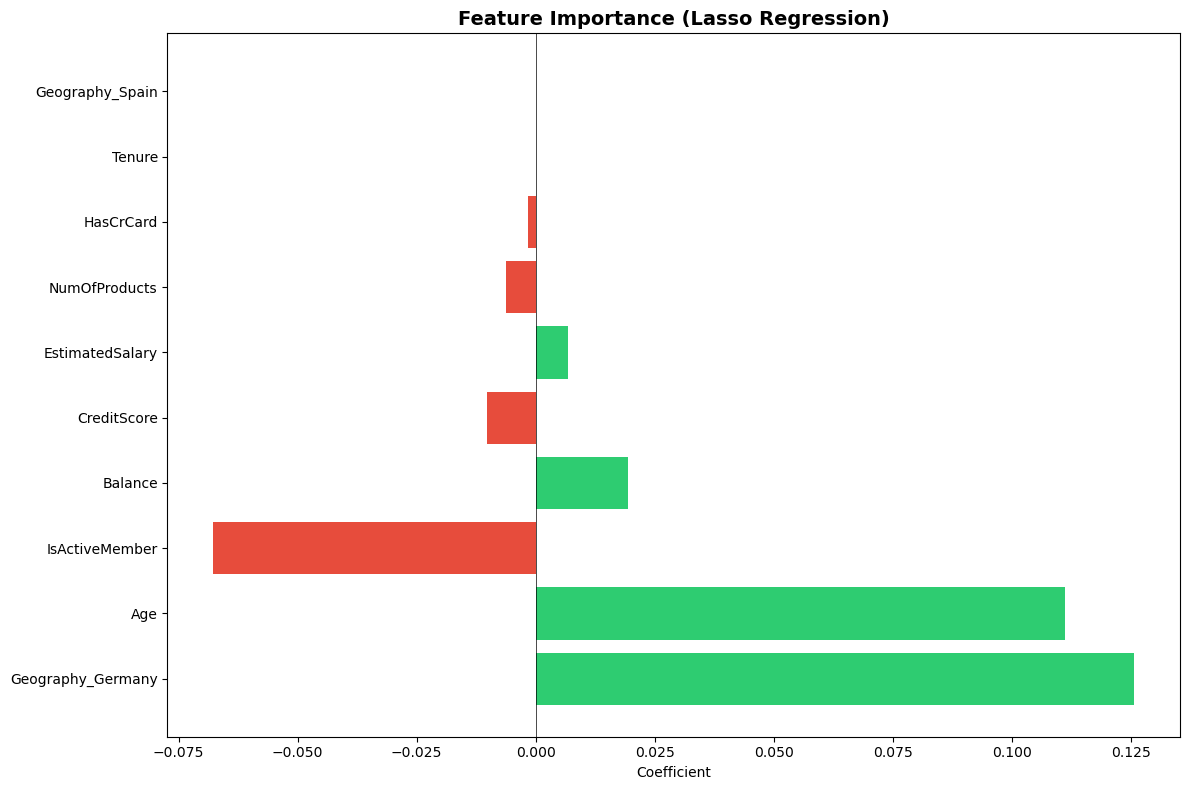


✅ FEATURE IMPORTANCE ANALİZİ TAMAMLANDI!


In [58]:
from sklearn.linear_model import LassoCV

print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Lasso ile feature importance
lasso_feature_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LassoCV(cv=5, max_iter=10000, random_state=42))
])

lasso_feature_pipeline.fit(X_train, y_train)

# Özellik isimlerini al
feature_names = (numeric_features + 
                 list(lasso_feature_pipeline.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .named_steps['onehot']
                      .get_feature_names_out(categorical_features)))

lasso_coef = lasso_feature_pipeline.named_steps['model'].coef_

# Önemli özellikleri sırala
importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lasso_coef
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop 10 En Önemli Özellikler:")
print(importance_df.head(10))

# Görselleştir
plt.figure(figsize=(12, 8))
top_features = importance_df.head(15)
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_features['coefficient']]
plt.barh(top_features['feature'], top_features['coefficient'], color=colors)
plt.xlabel('Coefficient')
plt.title('Feature Importance (Lasso Regression)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\n✅ FEATURE IMPORTANCE ANALİZİ TAMAMLANDI!")